# Generate Synthetic Data

Verify the data looks right

## Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
print(os.getcwd())

C:\Users\bumba\OneDrive\Desktop\supply-chain-demand-forecasting\notebooks


Load and inspect the data

In [2]:
demand_df = pd.read_csv("../data/raw/daily_demand.csv", parse_dates=["date"])
products_df = pd.read_csv("../data/raw/products.csv")
warehouses_df = pd.read_csv("../data/raw/warehouses.csv")

In [3]:
print(demand_df.shape)
demand_df.head()

(36500, 4)


,date,product_id,warehouse_id,units_sold
0,2024-01-01,1,1,57.0
1,2024-01-02,1,1,67.0
2,2024-01-03,1,1,65.0
3,2024-01-04,1,1,90.0
4,2024-01-05,1,1,62.0


Check for basic data quality issues

In [4]:
print("Missing values per column:")
print(demand_df.isnull().sum())

print("\nDate range:", demand_df["date"].min(), "to", demand_df["date"].max())

print("\nNegative units_sold rows:", (demand_df["units_sold"] < 0).sum())

print("\nUnique product/warehouse combinations:", 
      demand_df.groupby(["product_id", "warehouse_id"]).ngroups)

Missing values per column:
date            0
product_id      0
warehouse_id    0
units_sold      0
dtype: int64

Date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00

Negative units_sold rows: 0

Unique product/warehouse combinations: 50


### Plot multiple series together for a broader view
 so far have only looked at Product 1 / Warehouse 1. Now look at a handful of series together to confirm variety across your dataset

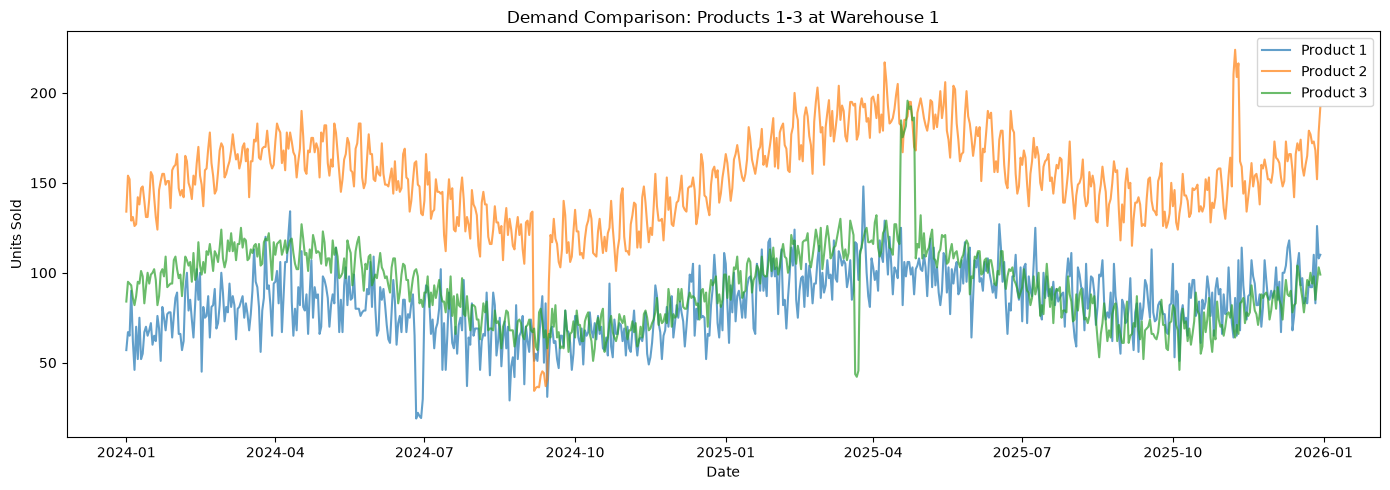

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

for pid in [1, 2, 3]:
    series = demand_df[(demand_df.product_id == pid) & (demand_df.warehouse_id == 1)]
    ax.plot(series["date"], series["units_sold"], label=f"Product {pid}", alpha=0.7)

ax.set_title("Demand Comparison: Products 1-3 at Warehouse 1")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()
plt.tight_layout()
plt.savefig("../dashboard/screenshots/demand_comparison.png")
plt.show()

### The core of this phase — seasonal decomposition
This is the most important cell in the whole phase. seasonal_decompose mathematically splits one time series into three separate components: trend, seasonal, and residual (leftover noise) — exactly the ingredients you built into the data, now being extracted back out to prove they're really there.

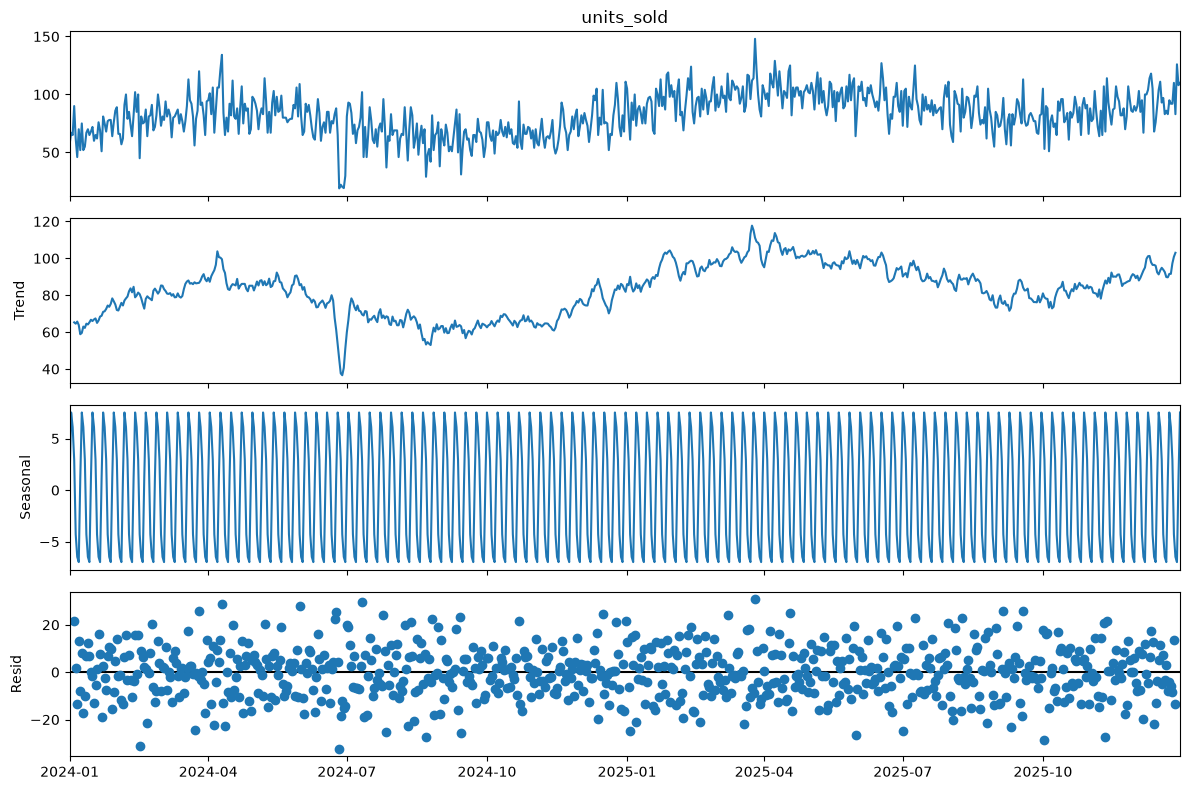

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Focus on one series for a clean decomposition
sample = demand_df[(demand_df.product_id == 1) & (demand_df.warehouse_id == 1)].copy()
sample = sample.set_index("date")["units_sold"]

# period=7 tells it to look for a repeating weekly cycle
decomposition = seasonal_decompose(sample, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("../dashboard/screenshots/seasonal_decomposition.png")
plt.show()

### Prepare the data in the exact shape Prophet expects
Prophet has a strict requirement: our input dataframe must have exactly two columns named ds (the date) and y (the value to forecast). This is a Prophet-specific convention, not a general pandas thing — worth knowing so you don't wonder why it's not date/units_sold.

In [7]:
# Pick one product/warehouse combination to model first
product_id = 1
warehouse_id = 1

series = demand_df[
    (demand_df.product_id == product_id) & (demand_df.warehouse_id == warehouse_id)
][["date", "units_sold"]].copy()

series = series.rename(columns={"date": "ds", "units_sold": "y"})
series = series.sort_values("ds").reset_index(drop=True)

print(series.shape)
series.head()

(730, 2)


,ds,y
0,2024-01-01,57.0
1,2024-01-02,67.0
2,2024-01-03,65.0
3,2024-01-04,90.0
4,2024-01-05,62.0


### Split into train and test
This is the single most important concept in this phase. With most machine learning data, you'd randomly shuffle and split into train/test. For time series, this is wrong — and explaining why is a great interview answer.

Why random splitting fails for time series: if you randomly pick 20% of days to be your "test set," some of those test days will fall before other training days chronologically. That means your model could accidentally "learn" from information that happened after the point it's supposed to be predicting — this is called data leakage, and it makes your evaluation dishonestly optimistic. In the real world, you never have future data when forecasting — your test method needs to respect that.

The correct approach: split by time — train on the earlier chunk, test on the most recent chunk, exactly mimicking how you'd actually use this model in production (train on history, forecast the next unseen period).

In [8]:
# Time-based split: train on first ~80%, test on final ~20%
split_point = int(len(series) * 0.8)

train = series.iloc[:split_point]
test = series.iloc[split_point:]

print(f"Train: {train['ds'].min()} to {train['ds'].max()} ({len(train)} days)")
print(f"Test:  {test['ds'].min()} to {test['ds'].max()} ({len(test)} days)")

Train: 2024-01-01 00:00:00 to 2025-08-06 00:00:00 (584 days)
Test:  2025-08-07 00:00:00 to 2025-12-30 00:00:00 (146 days)


### Fit the Prophet model — understanding every parameter

In [9]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model.fit(train)

Importing plotly failed. Interactive plots will not work.
15:16:36 - cmdstanpy - INFO - Chain [1] start processing
15:16:36 - cmdstanpy - INFO - Chain [1] done processing


### Generate the forecast

In [10]:
# Create a dataframe extending into the future, covering the test period
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# Extract just the forecasted values for the test period specifically
forecast_test_period = forecast.tail(len(test))

forecast_test_period.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
584,2025-08-07,94.709212,72.162465,103.696485,94.709212,94.709212,-6.951274,-6.951274,-6.951274,3.355409,3.355409,3.355409,-10.306683,-10.306683,-10.306683,0.0,0.0,0.0,87.757938
585,2025-08-08,94.761882,63.930211,94.539464,94.761882,94.761882,-15.135058,-15.135058,-15.135058,-4.382788,-4.382788,-4.382788,-10.752270,-10.752270,-10.752270,0.0,0.0,0.0,79.626824
586,2025-08-09,94.814552,61.322237,91.653634,94.814552,94.814552,-17.581911,-17.581911,-17.581911,-6.399413,-6.399413,-6.399413,-11.182498,-11.182498,-11.182498,0.0,0.0,0.0,77.232641
587,2025-08-10,94.867222,61.216853,91.443233,94.867222,94.867222,-19.135444,-19.135444,-19.135444,-7.540291,-7.540291,-7.540291,-11.595152,-11.595152,-11.595152,0.0,0.0,0.0,75.731779
588,2025-08-11,94.919892,68.647200,99.105245,94.919892,94.919892,-10.877073,-10.877073,-10.877073,1.111391,1.111391,1.111391,-11.988465,-11.988465,-11.988465,0.0,0.0,0.0,84.042819


### Visualize actual vs. predicted

In [11]:
import os

project_root = os.getcwd()
if os.path.basename(project_root) == "notebooks":
    project_root = os.path.dirname(project_root)

print("Project root:", project_root)

Project root: C:\Users\bumba\OneDrive\Desktop\supply-chain-demand-forecasting


In [12]:
print(demand_df.shape)

(36500, 4)


Saved to: C:\Users\bumba\OneDrive\Desktop\supply-chain-demand-forecasting\dashboard\screenshots\forecast_vs_actual.png


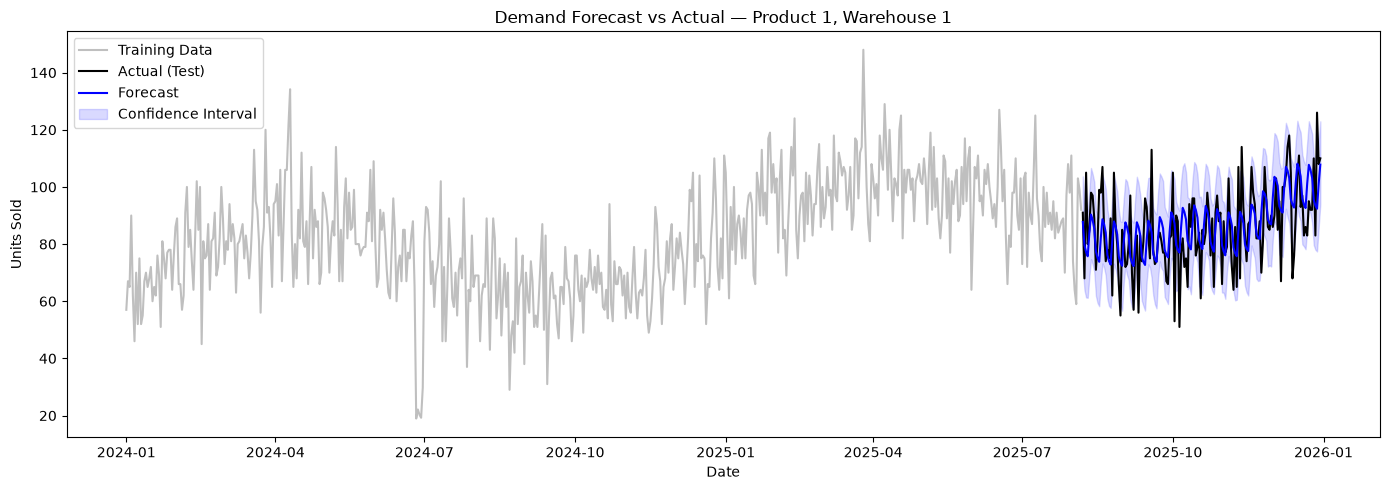

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train["ds"], train["y"], label="Training Data", color="gray", alpha=0.5)
ax.plot(test["ds"], test["y"], label="Actual (Test)", color="black")
ax.plot(forecast_test_period["ds"], forecast_test_period["yhat"], 
        label="Forecast", color="blue")
ax.fill_between(forecast_test_period["ds"], 
                 forecast_test_period["yhat_lower"], 
                 forecast_test_period["yhat_upper"], 
                 color="blue", alpha=0.15, label="Confidence Interval")

ax.set_title(f"Demand Forecast vs Actual — Product {product_id}, Warehouse {warehouse_id}")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()
plt.tight_layout()

save_path = os.path.join(project_root, "dashboard", "screenshots", "forecast_vs_actual.png")
plt.savefig(save_path)
print("Saved to:", save_path)
plt.show()

### Evaluate properly with MAE and MAPE

In [14]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

actual = test["y"].values
predicted = forecast_test_period["yhat"].values

mae = mean_absolute_error(actual, predicted)
mape = mean_absolute_percentage_error(actual, predicted) * 100  # convert to percentage

print(f"MAE:  {mae:.2f} units")
print(f"MAPE: {mape:.2f}%")

MAE:  9.81 units
MAPE: 12.14%


### Repeat for a second product to show generalization

In [15]:
def evaluate_product_forecast(demand_df, product_id, warehouse_id, test_frac=0.2):
    series = demand_df[
        (demand_df.product_id == product_id) & (demand_df.warehouse_id == warehouse_id)
    ][["date", "units_sold"]].rename(columns={"date": "ds", "units_sold": "y"}).sort_values("ds").reset_index(drop=True)

    split_point = int(len(series) * (1 - test_frac))
    train = series.iloc[:split_point]
    test = series.iloc[split_point:]

    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, 
                     daily_seasonality=False, changepoint_prior_scale=0.05)
    model.fit(train)

    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))

    mae = mean_absolute_error(test["y"], forecast_test["yhat"])
    mape = mean_absolute_percentage_error(test["y"], forecast_test["yhat"]) * 100

    return {"product_id": product_id, "warehouse_id": warehouse_id, "mae": mae, "mape": mape}

# Test on a few different series
results = []
for pid, wid in [(1, 1), (5, 3), (8, 2)]:
    result = evaluate_product_forecast(demand_df, pid, wid)
    results.append(result)
    print(result)

15:16:37 - cmdstanpy - INFO - Chain [1] start processing
15:16:37 - cmdstanpy - INFO - Chain [1] done processing
15:16:37 - cmdstanpy - INFO - Chain [1] start processing
15:16:37 - cmdstanpy - INFO - Chain [1] done processing


{'product_id': 1, 'warehouse_id': 1, 'mae': 9.805407421732637, 'mape': 12.14223936695547}


15:16:38 - cmdstanpy - INFO - Chain [1] start processing
15:16:38 - cmdstanpy - INFO - Chain [1] done processing


{'product_id': 5, 'warehouse_id': 3, 'mae': 9.142557092952991, 'mape': 5.695592232535593}
{'product_id': 8, 'warehouse_id': 2, 'mae': 7.535000221240265, 'mape': 11.081868974753284}


### let's Save our best evaluation results

In [16]:
results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv(os.path.join(project_root, "data", "processed", "forecast_evaluation.csv"), index=False)

   product_id  warehouse_id       mae       mape
0           1             1  9.805407  12.142239
1           5             3  9.142557   5.695592
2           8             2  7.535000  11.081869


In [17]:
import sys

if project_root not in sys.path:
    sys.path.append(project_root)

print("Added to path:", project_root)

Added to path: C:\Users\bumba\OneDrive\Desktop\supply-chain-demand-forecasting


In [18]:
with open(os.path.join(project_root, "forecasting", "inventory_optimizer.py")) as f:
    print(f.read())

"""
inventory_optimizer.py

Translates demand forecasts into concrete inventory decisions: safety stock,
reorder point, and economic order quantity (EOQ). Also includes a simple
simulation to compare a naive inventory policy against an optimized one,
quantifying the cost impact of the difference.
"""

import numpy as np
from scipy.stats import norm


def calculate_safety_stock(demand_std, lead_time_days, service_level=0.95):
    """
    Safety Stock = Z(service_level) * demand_std * sqrt(lead_time)
    """
    z = norm.ppf(service_level)
    return z * demand_std * np.sqrt(lead_time_days)


def calculate_reorder_point(avg_daily_demand, lead_time_days, safety_stock):
    """
    Reorder Point = (avg daily demand * lead time) + safety stock
    """
    return (avg_daily_demand * lead_time_days) + safety_stock


def calculate_eoq(annual_demand, order_cost, holding_cost_per_unit):
    """
    Economic Order Quantity: the order size that minimizes total 
    ordering + holding cost.
    EOQ

### Test

In [19]:
from forecasting.inventory_optimizer import calculate_safety_stock, calculate_reorder_point

In [20]:
# Get real stats for Product 1, Warehouse 1
series = demand_df[(demand_df.product_id == 1) & (demand_df.warehouse_id == 1)]

avg_daily_demand = series["units_sold"].mean()
demand_std = series["units_sold"].std()

# Get this product's lead time from your products table
lead_time = products_df[products_df.product_id == 1]["lead_time_days"].values[0]

print(f"Avg daily demand: {avg_daily_demand:.2f}")
print(f"Demand std dev: {demand_std:.2f}")
print(f"Lead time: {lead_time} days")

from forecasting.inventory_optimizer import calculate_safety_stock, calculate_reorder_point

safety_stock = calculate_safety_stock(demand_std, lead_time, service_level=0.95)
reorder_point = calculate_reorder_point(avg_daily_demand, lead_time, safety_stock)

print(f"\nRecommended safety stock: {safety_stock:.0f} units")
print(f"Recommended reorder point: {reorder_point:.0f} units")

Avg daily demand: 82.92
Demand std dev: 18.43
Lead time: 14 days

Recommended safety stock: 113 units
Recommended reorder point: 1274 units


### Run the comparison — naive vs. optimized

In [21]:
import sys
sys.path.append(project_root)

In [22]:
from forecasting.inventory_optimizer import simulate_inventory_policy

demand_values = series["units_sold"].values
unit_cost = products_df[products_df.product_id == 1]["unit_cost"].values[0]

# Naive policy: arbitrary fixed reorder point (e.g., a simple guess, no formula behind it)
naive_reorder_point = avg_daily_demand * lead_time  # no safety stock buffer at all
naive_order_qty = avg_daily_demand * lead_time * 2  # arbitrary round order size

naive_result = simulate_inventory_policy(
    demand_values, naive_reorder_point, naive_order_qty, 
    lead_time, starting_stock=avg_daily_demand * lead_time, unit_cost=unit_cost
)

# Optimized policy: using your calculated safety stock and reorder point
optimized_order_qty = avg_daily_demand * lead_time * 2  # keep order size same for fair comparison
optimized_result = simulate_inventory_policy(
    demand_values, reorder_point, optimized_order_qty, 
    lead_time, starting_stock=avg_daily_demand * lead_time, unit_cost=unit_cost
)

print("=== Naive Policy (no safety stock buffer) ===")
print(f"Stockout days: {naive_result['stockout_days']}")
print(f"Total cost: ${naive_result['total_cost']:.2f}")

print("\n=== Optimized Policy (forecast-driven safety stock) ===")
print(f"Stockout days: {optimized_result['stockout_days']}")
print(f"Total cost: ${optimized_result['total_cost']:.2f}")

savings = naive_result['total_cost'] - optimized_result['total_cost']
stockout_reduction = naive_result['stockout_days'] - optimized_result['stockout_days']
print(f"\nStockout days reduced by: {stockout_reduction}")
print(f"Estimated cost savings: ${savings:.2f}")

=== Naive Policy (no safety stock buffer) ===
Stockout days: 21
Total cost: $1114369.58

=== Optimized Policy (forecast-driven safety stock) ===
Stockout days: 9
Total cost: $428656.26

Stockout days reduced by: 12
Estimated cost savings: $685713.31


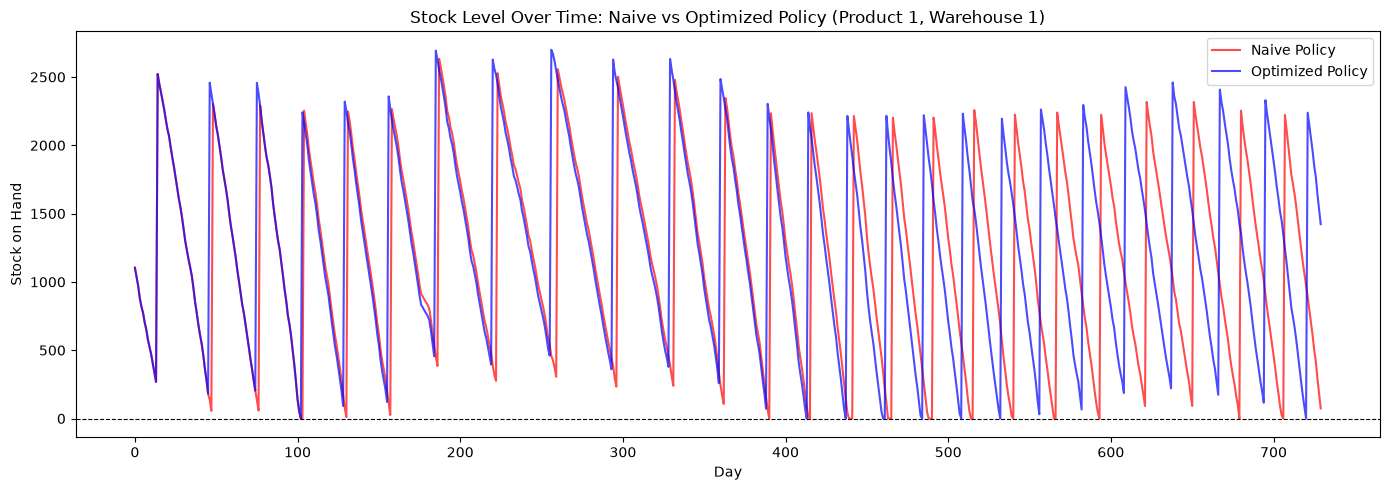

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(naive_result["stock_history"], label="Naive Policy", color="red", alpha=0.7)
ax.plot(optimized_result["stock_history"], label="Optimized Policy", color="blue", alpha=0.7)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Stock Level Over Time: Naive vs Optimized Policy (Product 1, Warehouse 1)")
ax.set_xlabel("Day")
ax.set_ylabel("Stock on Hand")
ax.legend()
plt.tight_layout()

save_path = os.path.join(project_root, "dashboard", "screenshots", "policy_comparison.png")
plt.savefig(save_path)
plt.show()

In [24]:
# In your notebook, after generating a forecast
forecast_export = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_export["product_id"] = product_id
forecast_export["warehouse_id"] = warehouse_id
forecast_export.to_csv(os.path.join(project_root, "data", "processed", "forecast_output.csv"), index=False)

In [25]:
import pandas as pd

policy_summary = pd.DataFrame([
    {"policy": "Naive", "stockout_days": naive_result["stockout_days"], "total_cost": naive_result["total_cost"]},
    {"policy": "Optimized", "stockout_days": optimized_result["stockout_days"], "total_cost": optimized_result["total_cost"]},
])
policy_summary.to_csv(os.path.join(project_root, "data", "processed", "policy_comparison.csv"), index=False)

unit_cost: 238.42
avg_daily_demand: 82.92
naive_reorder_point: 1160.89
naive_order_qty: 2321.77
lead_time: 14

First 20 stock values: [np.float64(1103.8867656814691), np.float64(1036.8867656814691), np.float64(971.8867656814691), np.float64(881.8867656814691), np.float64(819.8867656814691), np.float64(773.8867656814691), np.float64(703.8867656814691), np.float64(651.8867656814691), np.float64(576.8867656814691), np.float64(524.8867656814691), np.float64(469.8867656814691), np.float64(402.8867656814691), np.float64(332.8867656814691), np.float64(267.8867656814691), np.float64(2521.6602970444073), np.float64(2449.6602970444073), np.float64(2389.6602970444073), np.float64(2324.6602970444073), np.float64(2262.6602970444073), np.float64(2186.6602970444073)]
Max stock value: 2632.7344965197162


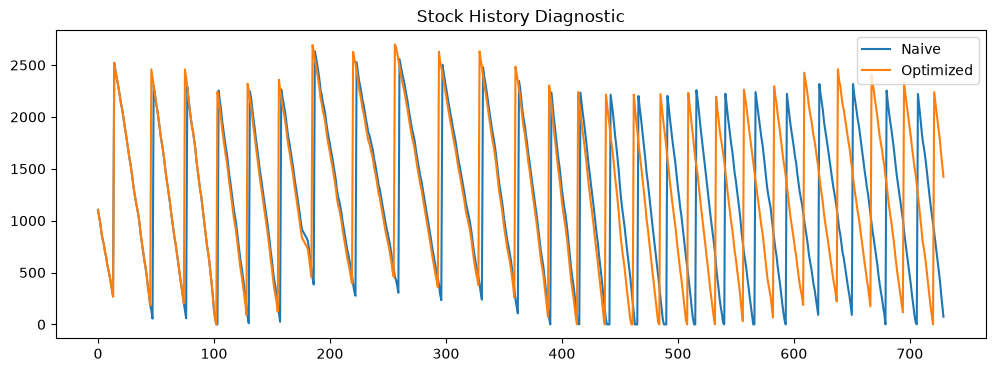

In [26]:
import matplotlib.pyplot as plt

print(f"unit_cost: {unit_cost}")
print(f"avg_daily_demand: {avg_daily_demand:.2f}")
print(f"naive_reorder_point: {naive_reorder_point:.2f}")
print(f"naive_order_qty: {naive_order_qty:.2f}")
print(f"lead_time: {lead_time}")
print()
print("First 20 stock values:", naive_result["stock_history"][:20])
print("Max stock value:", max(naive_result["stock_history"]))

plt.figure(figsize=(12, 4))
plt.plot(naive_result["stock_history"], label="Naive")
plt.plot(optimized_result["stock_history"], label="Optimized")
plt.title("Stock History Diagnostic")
plt.legend()
plt.show()

In [27]:
import pandas as pd

policy_summary = pd.DataFrame([
    {"policy": "Naive", "stockout_days": naive_result["stockout_days"], "total_cost": naive_result["total_cost"]},
    {"policy": "Optimized", "stockout_days": optimized_result["stockout_days"], "total_cost": optimized_result["total_cost"]},
])
policy_summary.to_csv(os.path.join(project_root, "data", "processed", "policy_comparison.csv"), index=False)

print(policy_summary)

      policy  stockout_days    total_cost
0      Naive             21  1.114370e+06
1  Optimized              9  4.286563e+05
